## Extension: More Three-body Choreographies

## Chloe Lin

**2025/03/18**

For the extension, I want to use the **velocity Verlet method** to investigate on different three-body choreographies, from the classic three‐body Lagrange (equilateral triangle) solution to the triple star system in the famous sci-fi *The Three-Body Problem*: Alpha Centauri.

### 1. Classic Rotating Lagrange solution$^{[1]}$

One of the most well-known solution to the Three-Body problem is **Lagrange's equilateral triangle solution**. The three bodies in the solution have identical masses: $m_1$ = $m_2$ = $m_3$ = $m$. They are placed at the corners of an equilateral triangle of side $R$, and their triangular configuration is maintained such that an equilateral triangle is formed at each instant. In this section we will calculate the initial positions and velocities of the three bodies, and propagate the system using the velocity Verlet integrator.

#### 1.1 Positions for an Equilateral Triangle
   
We set the centre of mass of the system to be at the origin $(0,0)$.

In a equilateral traingle of side $R$, the distance from the centre to each vertex is found by Pythagorean theorem to be:
$$\frac{R}{\sqrt{3}}$$
We can place the first vertex on the $+y$-axis for convenience:
$$ \mathbf{r}_1 = (0,+\frac{R}{\sqrt{3}})$$
The next two vertices can be found by rotating $\mathbf{r}_1$ by $\pm 120°$. A 2D rotation by an angle $\theta$ is given by the matrix:
$$R(\theta) = \begin{pmatrix} cos\theta & -sin\theta \\ sin\theta & cos\theta \end{pmatrix}$$
So 
$$\mathbf{r}_2 =R(+120°) = \begin{pmatrix} cos120° & -sin120° \\ sin120° & cos120° \end{pmatrix} \begin{pmatrix} +\frac{R}{\sqrt{3}} \\ 0 \end{pmatrix}= \begin{pmatrix} -\frac{R}{2} \\ -\frac{R}{2\sqrt{3}} \end{pmatrix}$$

$$\mathbf{r}_3 =R(-120°) =\begin{pmatrix} cos(-120°) & -sin(-120°) \\ sin(-120°) & cos(-120°) \end{pmatrix} \begin{pmatrix} +\frac{R}{\sqrt{3}} \\ 0 \end{pmatrix}= \begin{pmatrix} \frac{R}{2} \\ -\frac{R}{2\sqrt{3}} \end{pmatrix}$$
These three points form an equilateral triangle of side $R$ centred at the origin $(0,0)$: this is the centre of mass of the system, which due to conservation of momentum would be expected remain in place.

#### 1.2 Velocities for the bodies

In the rotating Lagrange solution, the gravitational force from the other two bodies provides the centripetal force. 

Consider $m_1$. The other two masses each exert a gravitational force of magnitude:
$$ F_{single} = \frac{Gm^2}{R^2} $$
However, these two forces act in different directions, since each is directed along the line from $m_1$ to the other mass. 

Since the triangle is equilateral, the two force vectors on $m_1$ each have magnitude $F = Gm^2/R^2$ and form a $60°$ angle with each other. Therefore the resultant of these two equal force vectors is:
$$ \sqrt{F^2+F^2+2FFcos(60°)} = \sqrt{3}F$$
Thus, the net radial force acting on one mass by the other two masses is:
$$F = \sqrt{3}\frac{Gm^2}{R^2} $$ directed towards the centre.

Equating this to the centripetal force:
$$ \sqrt{3}\frac{Gm^2}{R^2} = \frac{mv^2}{r} =\frac{mv^2}{R/\sqrt{3}} $$
Simplify to get:
$$v^2 = \frac{Gm}{R}$$
$$v = \sqrt{\frac{Gm}{R}}$$

Therefore we found that all three masses orbit around the origin at speed $v = \sqrt{\frac{Gm}{R}}$. Notice that the velocities $v_i$ are tangential to the positions $r_i$.

In [2]:
%matplotlib inline

In [3]:
import numpy as np
import matplotlib.pyplot as plt

#### 1.3 Set up initial conditions

In [5]:
# Set up parameters
G = 1.0
m_Lagrange = 1.0  # All masses are the same
R = 1.0  # Side length of the equilateral triangle

# Initial positions of each mass
r1_Lagrange = np.array([0.0,R/np.sqrt(3)])
r2_Lagrange = np.array([-R/2,-R/(2*np.sqrt(3))])
r3_Lagrange = np.array([R/2,-R/(2*np.sqrt(3))])

# Initial speed of each mass
v_Lagrange = np.sqrt(G*m_Lagrange/R)

# Define a function to obtain tangential velocity
def tangential_v(v,pos):
    """ Calculate the velocity v_i perpendicular to normalised positions r_i
    Input: 
    - v      Speed
    - pos    Position vector r_i
    """
    r_norm = np.linalg.norm(pos)
    perp = np.array([-pos[1],pos[0]])
    v_perp = v*perp/r_norm
    return v_perp

v1_Lagrange = tangential_v(v_Lagrange,r1_Lagrange)
v2_Lagrange = tangential_v(v_Lagrange,r2_Lagrange)
v3_Lagrange = tangential_v(v_Lagrange,r3_Lagrange)

# Print out the initial values for clarity
print("r1 =", r1_Lagrange, "v1 =", v1_Lagrange)
print("r2 =", r2_Lagrange, "v2 =", v2_Lagrange)
print("r3 =", r3_Lagrange, "v3 =", v3_Lagrange)

r1 = [0.         0.57735027] v1 = [-1.  0.]
r2 = [-0.5        -0.28867513] v2 = [ 0.5       -0.8660254]
r3 = [ 0.5        -0.28867513] v3 = [0.5       0.8660254]


In [6]:
# Define a function to compute gravitational force on each mass for the velocity Verlet update loop
def three_body_forces(r1,r2,r3,m,G):
    """Compute the net gravitational force on three bodies.
    Inputs:
    - r1,r2,r3    Position vectors of the 3 bodies
    - m           Mass (all 3 masses are equal)
    - G           Gravitational constant
    
    Returns:
    F1,F2,F3: force vectors on body 1,2,3 respectively.
    """
    F1 = np.zeros(2)
    F2 = np.zeros(2)
    F3 = np.zeros(2)
    
    # Force on 1 from 2 and 3
    r12 = r2-r1
    r13 = r3-r1
    F1 += G*m*m*r12 / (np.linalg.norm(r12)**3)
    F1 += G*m*m*r13 / (np.linalg.norm(r13)**3)
    # Force on 2 from 1 and 3
    r21 = r1-r2
    r23 = r3-r2
    F2 += G*m*m*r21 / (np.linalg.norm(r21)**3)
    F2 += G*m*m*r23 / (np.linalg.norm(r23)**3)
    # Force on 3 from 1 and 2
    r31 = r1-r3
    r32 = r2-r3
    F3 += G*m*m*r31 / (np.linalg.norm(r31)**3)
    F3 += G*m*m*r32 / (np.linalg.norm(r32)**3)
    
    return F1, F2, F3

**2025/3/19**: I think making the velocity Verlet loop into a function seem to be a more straightforward and convenient approach for me, since I might run the simulation again later to test for different initial conditions and reusing the function would be easier than writing another loop.

**2025/3/19**: I will also compute a function that calculates all energies and angular momentum for convenience: I can just call this function in the velocity Verlet integrator function. **Maybe I should have done these earlier :(**

In [8]:
# Function to calculate the energies and angular momentum of the three bodies
def three_body_energies(r1, r2, r3, v1, v2, v3, m, G):
    """
    Compute kinetic energy, potential energy, total energy and angular momentum of the system.
    
    Inputs:
    - r1,r2,r3   Position vectors of the three bodies
    - v1,v2,v3   Velocity vectors of the three bodies
    - m          Mass of the three bodies (identical masses)
    - G          Gravitational constant
    
    Returns:
    - KE         Kinetic energy
    - PE         Potential energy 
    - E_total    KE + PE
    - L          Total angular momentum 
    """
    # Kinetic Energy: KE = 0.5*m*(v1^2 + v2^2 + v3^2)
    KE = 0.5*m*(np.linalg.norm(v1)**2 + np.linalg.norm(v2)**2 + np.linalg.norm(v3)**2)
    # Potential Energy: PE = -G*m^2/r
    r12 = np.linalg.norm(r2-r1)
    r13 = np.linalg.norm(r3-r1)
    r23 = np.linalg.norm(r3-r2)
    PE = -G*m*m*(1/r12 + 1/r13 + 1/r23)
    E_total = KE + PE
    
    # Angular momentum: L = m*(x*v_y - y*v_x)
    L1 = m*(r1[0]*v1[1] - r1[1]*v1[0])
    L2 = m*(r2[0]*v2[1] - r2[1]*v2[0])
    L3 = m*(r3[0]*v3[1] - r3[1]*v3[0])
    L = L1 + L2 + L3
    
    return KE, PE, E_total, L

In [9]:
# Function of velocity Verlet Integrator for the 3-body system
def velocity_verlet_3body(r1_init, r2_init, r3_init, v1_init, v2_init, v3_init, m, G, dt, N):
    """
    Propagate a three-body system using the velocity Verlet method
    
    Inputs:
    - r1_init, r2_init, r3_init   Initial positions (each a 2-element array)
    - v1_init, v2_init, v3_init   Initial velocities (each a 2-element array)
    - m                           Mass of each body
    - G                           Gravitational constant
    - dt                          Timestep
    - N                           Number of steps
      
    Returns:
      r1, r2, r3: arrays of shape (N+1,2) containing positions
      v1, v2, v3: arrays of shape (N+1,2) containing velocities
      KE, PE, E_total, L: arrays of length N+1 for energies and angular momentum
    """
    # Set up arrays to store positions and velocities
    r1 = np.zeros((N+1,2))
    r2 = np.zeros((N+1,2))
    r3 = np.zeros((N+1,2))
    v1 = np.zeros((N+1,2))
    v2 = np.zeros((N+1,2))
    v3 = np.zeros((N+1,2))
    # Set up arrays to store energies and angular momentum
    KE = np.zeros(N+1)
    PE = np.zeros(N+1)
    E_total = np.zeros(N+1)
    L = np.zeros(N+1)
    # Set initial conditions
    r1[0] = r1_init
    r2[0] = r2_init
    r3[0] = r3_init
    v1[0] = v1_init
    v2[0] = v2_init
    v3[0] = v3_init
    
    # Compute initial forces
    F1, F2, F3 = three_body_forces(r1_init, r2_init, r3_init, m, G)
    # Compute initial energies and angular momentum
    KE[0], PE[0], E_total[0], L[0] = three_body_energies(r1_init, r2_init, r3_init, 
                                                         v1_init, v2_init, v3_init, m, G)
    
    # Time integration loop
    for i in range(N):
        # Update positions
        r1_new = r1[i] + v1[i]*dt + 0.5*(F1/m)*dt**2
        r2_new = r2[i] + v2[i]*dt + 0.5*(F2/m)*dt**2
        r3_new = r3[i] + v3[i]*dt + 0.5*(F3/m)*dt**2
        # Compute new forces at updated positions
        F1_new, F2_new, F3_new = three_body_forces(r1_new, r2_new, r3_new, m, G)
        # Update velocities
        v1_new = v1[i] + 0.5*((F1+F1_new)/m)*dt
        v2_new = v2[i] + 0.5*((F2+F2_new)/m)*dt
        v3_new = v3[i] + 0.5*((F3+F3_new)/m)*dt
        # Store new positions and velocities
        r1[i+1] = r1_new
        r2[i+1] = r2_new
        r3[i+1] = r3_new
        v1[i+1] = v1_new
        v2[i+1] = v2_new
        v3[i+1] = v3_new
        # Compute energies and angular momentum at new positions
        KE_new, PE_new, E_total_new, L_new = three_body_energies(r1_new, r2_new, r3_new, 
                                                                 v1_new, v2_new, v3_new, m, G)
        KE[i+1] = KE_new
        PE[i+1] = PE_new
        E_total[i+1] = E_total_new
        L[i+1] = L_new
        
        # Update forces for next iteration
        F1, F2, F3 = F1_new, F2_new, F3_new
        
    return r1, r2, r3, v1, v2, v3, KE, PE, E_total, L

#### 1.4 Run the simulation and create plots

In [11]:
# Run simulation
dt = 0.001
total_t = 20.0
N = int(total_t / dt)
t = np.linspace(0,total_t,N+1)
r1, r2, r3, v1, v2, v3, KE, PE, E_total, L = velocity_verlet_3body(r1_Lagrange, r2_Lagrange, r3_Lagrange,
                                                                   v1_Lagrange, v2_Lagrange, v3_Lagrange, m_Lagrange,
                                                                   G, dt, N)

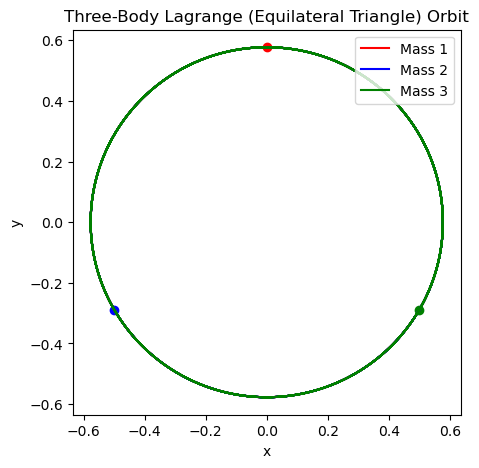

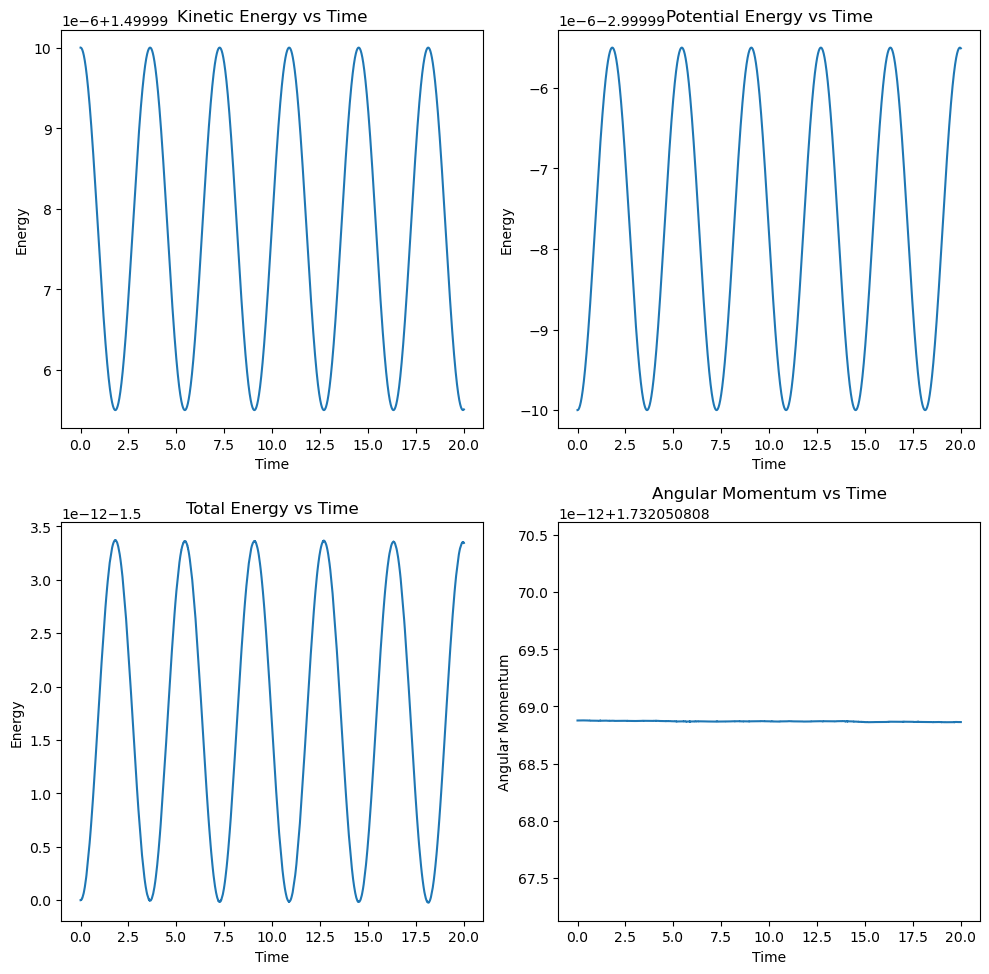

In [12]:
# Plot orbits
plt.figure(figsize=(5,5))
plt.plot(r1[:,0],r1[:,1],label="Mass 1",color="red")
plt.plot(r2[:,0],r2[:,1],label="Mass 2",color="blue")
plt.plot(r3[:,0],r3[:,1],label="Mass 3",color="green")
plt.scatter(r1_Lagrange[0],r1_Lagrange[1],color="red")
plt.scatter(r2_Lagrange[0],r2_Lagrange[1],color="blue")
plt.scatter(r3_Lagrange[0],r3_Lagrange[1],color="green")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Three-Body Lagrange (Equilateral Triangle) Orbit")
plt.legend(loc='upper right')
plt.show()

# Plot kinetic energy vs time
fig1_3body = plt.figure(figsize=(10,10),tight_layout=True)
fig1_3body_1 = fig1_3body.add_subplot(2,2,1)
fig1_3body_1.plot(t,KE)
fig1_3body_1.set_xlabel("Time")
fig1_3body_1.set_ylabel("Energy")
fig1_3body_1.set_title("Kinetic Energy vs Time")

# Plot potential energy vs time
fig1_3body_2 = fig1_3body.add_subplot(2,2,2)
fig1_3body_2.plot(t,PE)
fig1_3body_2.set_xlabel("Time")
fig1_3body_2.set_ylabel("Energy")
fig1_3body_2.set_title("Potential Energy vs Time")

# Plot total energy vs time
fig1_3body_3 = fig1_3body.add_subplot(2,2,3)
fig1_3body_3.plot(t,E_total)
fig1_3body_3.set_xlabel("Time")
fig1_3body_3.set_ylabel("Energy")
fig1_3body_3.set_title("Total Energy vs Time")

# Plot angular momentum vs time
fig1_3body_4 = fig1_3body.add_subplot(2,2,4)
fig1_3body_4.plot(t,L)
fig1_3body_4.set_xlabel("Time")
fig1_3body_4.set_ylabel("Angular Momentum")
fig1_3body_4.set_title("Angular Momentum vs Time")

plt.show()

From the plots we can see that the orbit remains stably circular, and the energy and angular momentum plots confirm everything is nicely conserved. These results are exactly what we would expect for a well‐implemented velocity Verlet simulation of the equilateral triangle Lagrange solution.

**2025/03/19**: At first I set `total_t` to $10.0$, the plots were perfect; then I set it to $20.0$ just to let it propagate for a longer period; then I tried with $30.0$ thinking it would give the same circular orbit but the plots were surprising: 

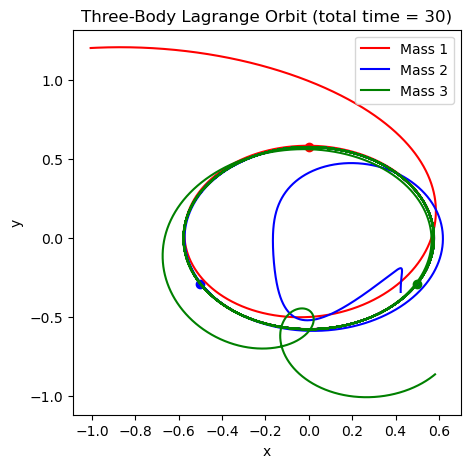

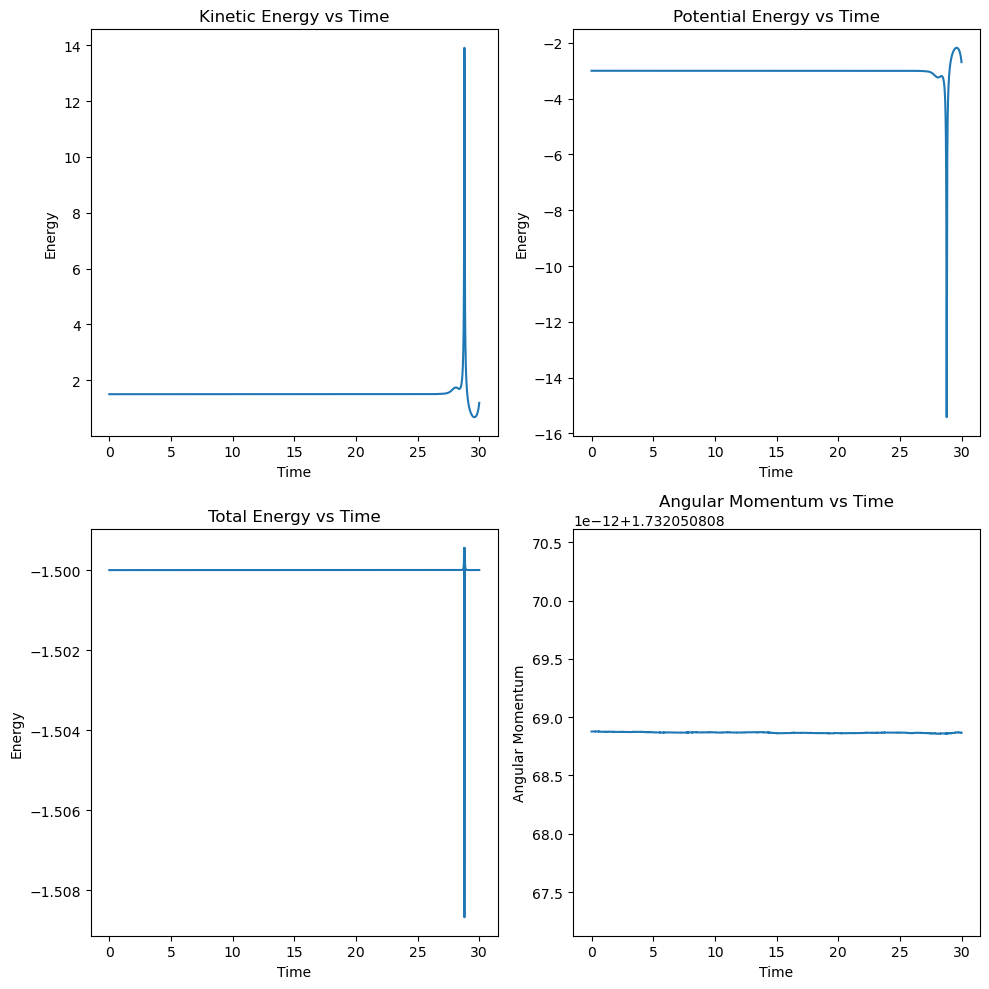

In [15]:
# Run simulation for total time = 30.0
dt = 0.001
total_t = 30.0
N = int(total_t / dt)
t = np.linspace(0,total_t,N+1)
r1, r2, r3, v1, v2, v3, KE, PE, E_total, L = velocity_verlet_3body(r1_Lagrange, r2_Lagrange, r3_Lagrange,
                                                                   v1_Lagrange, v2_Lagrange, v3_Lagrange, m_Lagrange,
                                                                   G, dt, N)
# Plot orbits
plt.figure(figsize=(5,5))
plt.plot(r1[:,0],r1[:,1],label="Mass 1",color="red")
plt.plot(r2[:,0],r2[:,1],label="Mass 2",color="blue")
plt.plot(r3[:,0],r3[:,1],label="Mass 3",color="green")
plt.scatter(r1_Lagrange[0],r1_Lagrange[1],color="red")
plt.scatter(r2_Lagrange[0],r2_Lagrange[1],color="blue")
plt.scatter(r3_Lagrange[0],r3_Lagrange[1],color="green")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Three-Body Lagrange Orbit (total time = 30)")
plt.legend(loc='upper right')
plt.show()

# Plot kinetic energy vs time
fig2_3body = plt.figure(figsize=(10,10),tight_layout=True)
fig2_3body_1 = fig2_3body.add_subplot(2,2,1)
fig2_3body_1.plot(t,KE)
fig2_3body_1.set_xlabel("Time")
fig2_3body_1.set_ylabel("Energy")
fig2_3body_1.set_title("Kinetic Energy vs Time")

# Plot potential energy vs time
fig2_3body_2 = fig2_3body.add_subplot(2,2,2)
fig2_3body_2.plot(t,PE)
fig2_3body_2.set_xlabel("Time")
fig2_3body_2.set_ylabel("Energy")
fig2_3body_2.set_title("Potential Energy vs Time")

# Plot total energy vs time
fig2_3body_3 = fig2_3body.add_subplot(2,2,3)
fig2_3body_3.plot(t,E_total)
fig2_3body_3.set_xlabel("Time")
fig2_3body_3.set_ylabel("Energy")
fig2_3body_3.set_title("Total Energy vs Time")

# Plot angular momentum vs time
fig2_3body_4 = fig2_3body.add_subplot(2,2,4)
fig2_3body_4.plot(t,L)
fig2_3body_4.set_xlabel("Time")
fig2_3body_4.set_ylabel("Angular Momentum")
fig2_3body_4.set_title("Angular Momentum vs Time")

plt.show()

This chaotic orbit is most likely to be due to numerical errors accumulated enough to destablise the orbit. Reducing the timestep $dt$ would be the most direct way to fix this. Even though velocity Verlet is time-reversible and good at conserving energy, the longer the simulation, the more important it is to have a sufficiently small time step.

### 1.2 Stability and Shapes of Orbits with Different Initial Velocities

**2025/03/20**

Now we are going to explore the stability and shapes of the three-body Lagrange orbit under different initial speed scalings:

#### 1.2.1 Define a velocity scaling parameter

In the previous section we have found that the initial velocity for the simple three-body Lagrange problem to maintain circular orbits is $v_0 = \sqrt{\frac{Gm}{R}}$.

Now we want to introduce a scaling factor $\alpha$, that scales our initial velocity by $\alpha$. After scaling all three bodies will have an initial tangential speed of $\alpha v_0$.

In [18]:
# Create a function to scale velocities
def scale(alpha, v1, v2, v3):
    """ Scale each velocity by a factor of alpha
    Inputs: 
    - alpha         The scaling parameter
    - v1, v2, v3    The velocities to be scaled
    Output:
    - Velocities scaled by alpha
    """
    v1_scaled = alpha*v1
    v2_scaled = alpha*v2
    v3_scaled = alpha*v3
    return v1_scaled, v2_scaled, v3_scaled

#### 1.2.2 Create a range of values of the parameter to test for

We will choose a range of $\alpha$ values to test for, e.g. $\alpha \in [0.5,2.0]$. We will then run the simulation for each $\alpha$ in small intervals.

In [20]:
# Test for a range of alpha from 0.1 to 2 with step size 0.05
alpha_values = np.arange(0.1,2.05,0.05) 
dt_test = 0.001
total_t_test = 10.0
N_test = int(total_t_test / dt_test)

#### 1.2.3 Find the "critical scaling parameter"

We want to find "critical values" for $\alpha$, for example, when $\alpha < a$  the system collapses, and when $\alpha >b$  the bodies escape from the system. 

To do this we need to quantify the stability. We can keep track of the distance among the bodies over time:
- If at least one of the distances between the bodies reduces to a very small value $d_{collapse}$, we have a near-collision.
- If at least one of the distances between the bodies grows to a very large value $d_{escape}$, one or more bodies might have escaped from the system.

In [22]:
# Create a function to check stability
def check_stability(r1_array, r2_array, r3_array, d_collide, d_escape):
    """
    Determine if the system is stable over the entire trajectory.
    If at any point any distance < d_collide or > d_escape, we determine that it's unstable.

    Inputs:
    - r1_array, r2_array, r3_array    Arrays of shape (N+1,2)
    - d_collide                       Threshold  distance for collision
    - d_escape                        Threshold distance for escape

    Output:
    stable_mark : 1 if stable, 0 if unstable
    """
    stable_mark = 1  # assume stable and mark as 1

    for i in range(len(r1_array)):
        r12 = np.linalg.norm(r2_array[i] - r1_array[i])
        r13 = np.linalg.norm(r3_array[i] - r1_array[i])
        r23 = np.linalg.norm(r3_array[i] - r2_array[i])
        min_d = min(r12, r13, r23)
        max_d = max(r12, r13, r23)

        if min_d < d_collide or max_d > d_escape:
            stable_mark = 0  # found instability and mark as 0

    return stable_mark

In [23]:
# Define the threshold distances for instability
d_collide = 0.1*R
d_escape  = 5.0*R

# Create an empty list to store the stability mark for each run
stability_marks = []

for alpha in alpha_values:
    # Scale velocities
    v1_scaled, v2_scaled, v3_scaled = scale(alpha, v1_Lagrange, v2_Lagrange, v3_Lagrange)
    
    # Run velocity Verlet for time total_t_test
    scaled_results = velocity_verlet_3body(r1_Lagrange, r2_Lagrange, r3_Lagrange,
                                           v1_scaled, v2_scaled, v3_scaled, m_Lagrange, G, dt_test, N_test)
    r1_scaled = scaled_results[0]
    r2_scaled = scaled_results[1]
    r3_scaled = scaled_results[2]
    
    # Check stability
    stable_mark = check_stability(r1_scaled, r2_scaled, r3_scaled,
                                  d_collide = d_collide,
                                  d_escape = d_escape)
    
    # Append the value of stable_flag (0 for unstable or 1 for stable) to the list.
    stability_marks.append(stable_mark)



#### 1.2.4 Plot results and interpret

First we will plot the stability of the orbits vs $\alpha$ to obtain some representative $\alpha$ values.

Then we will plot the orbits, total energies and angular momentum for these $\alpha$ values. From the plots we will be able to visualise the sensitivity of the Lagrange system to changes in the initial velocity magnitude.

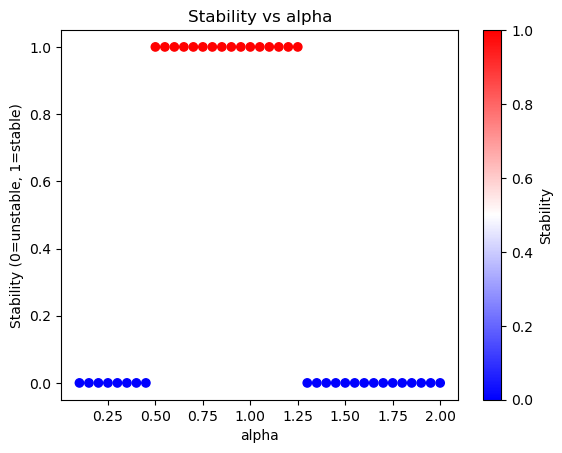

In [25]:
# Now plot alpha vs stability
plt.figure()
plt.scatter(alpha_values, stability_marks, c=stability_marks, cmap='bwr')
plt.xlabel("alpha")
plt.ylabel("Stability (0=unstable, 1=stable)")
plt.title("Stability vs alpha")
plt.colorbar(label="Stability")
plt.show()

From this plot we can see that the system becomes unstable when $\alpha$ is $<\approx 0.5$ and $\alpha>\approx 1.25$ if we define being unstable as "at least one of the distances between the bodies is less than $0.1R$ or more than $5R$". This is consistent with the idea that if the velocity is too small, the bodies can’t sustain their orbital separation and collapse inward, while if it’s too large, the system can fling bodies outward.

We can verify this claim by creating detailed plots for $\alpha$ around these "critical values" to see what actually happens.

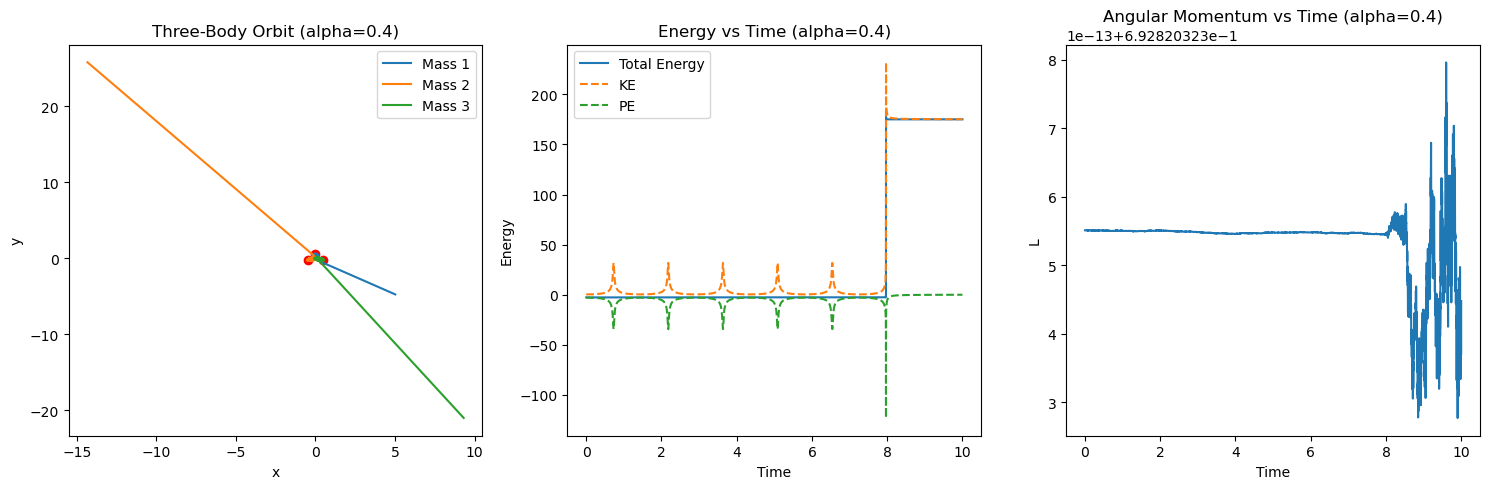

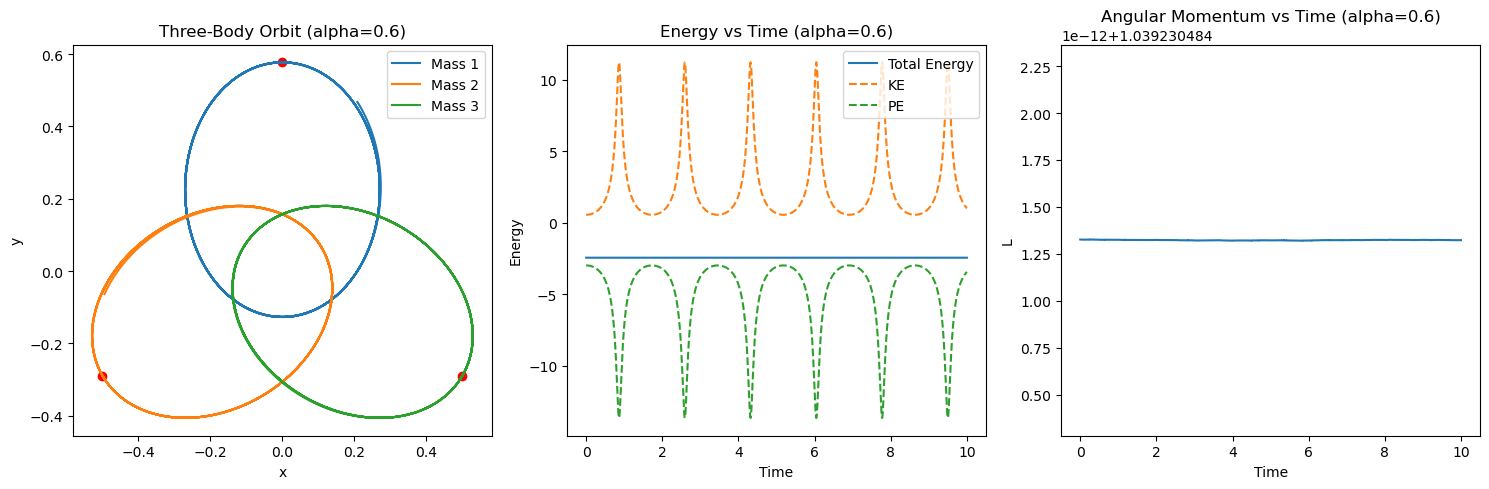

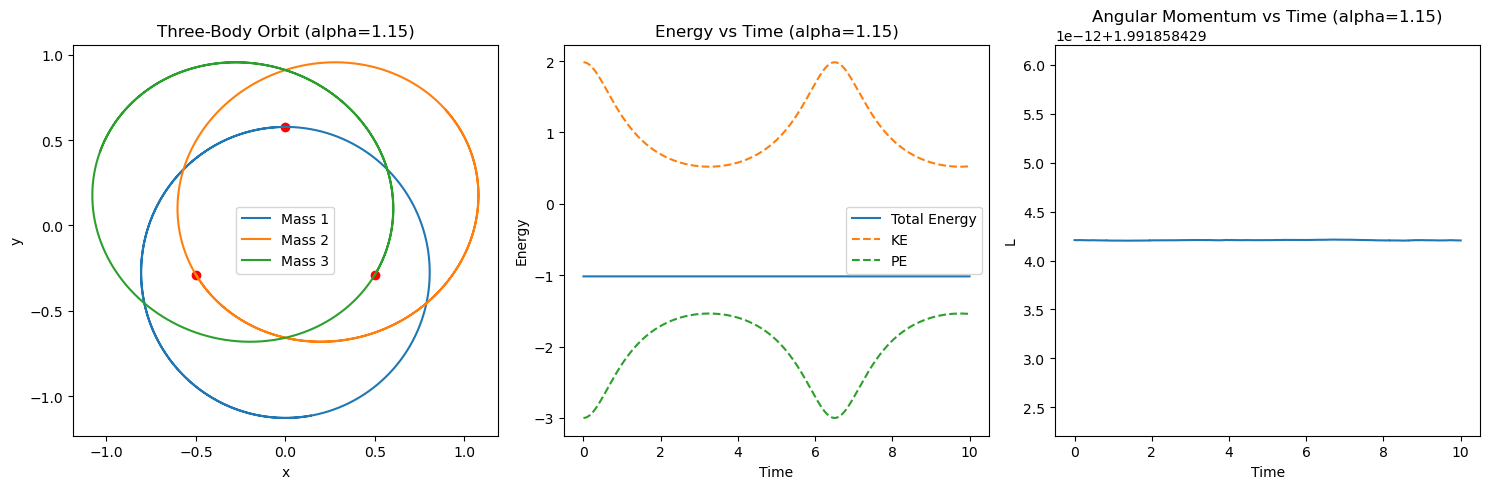

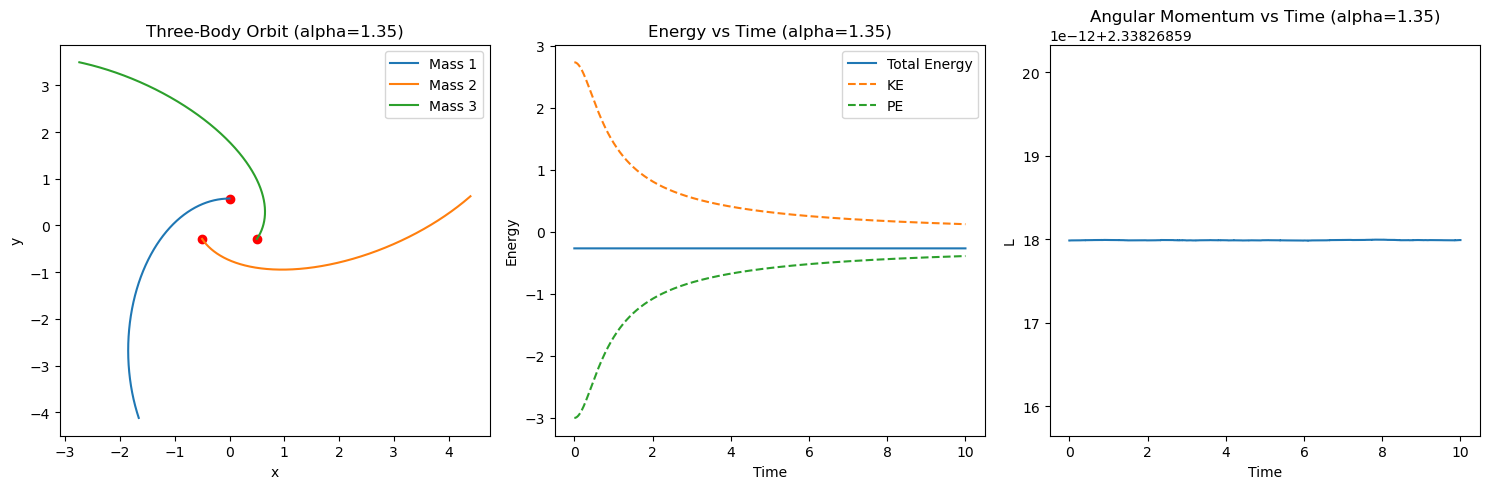

In [27]:
# Plots for critical alpha values
alpha_rep = [0.4, 0.6, 1.15, 1.35] 
dt = 0.001
total_t = 10.0
N = int(total_t / dt)

for alpha in alpha_rep:
    v1_scaled, v2_scaled, v3_scaled = scale(alpha, v1_Lagrange, v2_Lagrange, v3_Lagrange)
    results = velocity_verlet_3body(r1_Lagrange, r2_Lagrange, r3_Lagrange,
                                    v1_scaled, v2_scaled, v3_scaled, m_Lagrange, G, dt, N)

    r1_new = results[0]
    r2_new = results[1]
    r3_new = results[2]
    KE = results[6]
    PE = results[7]
    E_total = results[8]
    L = results[9]
    
    t = np.linspace(0, total_t, N+1)
    
    # Plot the orbit
    plt.figure(figsize=(15,5))
    plt.subplot(1,3,1)
    plt.plot(r1_new[:,0], r1_new[:,1], label="Mass 1")
    plt.plot(r2_new[:,0], r2_new[:,1], label="Mass 2")
    plt.plot(r3_new[:,0], r3_new[:,1], label="Mass 3")
    plt.scatter(r1_new[0,0], r1_new[0,1], color="red")  
    plt.scatter(r2_new[0,0], r2_new[0,1], color="red")
    plt.scatter(r3_new[0,0], r3_new[0,1], color="red")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"Three-Body Orbit (alpha={alpha})")
    plt.legend(loc='best')
    
    # Plot total energy
    plt.subplot(1,3,2)
    plt.plot(t, E_total, label="Total Energy")
    plt.plot(t, KE, label="KE", linestyle="--")
    plt.plot(t, PE, label="PE", linestyle="--")
    plt.xlabel("Time")
    plt.ylabel("Energy")
    plt.title(f"Energy vs Time (alpha={alpha})")
    plt.legend(loc='best')
    
    # Plot angular momentum
    plt.subplot(1,3,3)
    plt.plot(t, L)
    plt.xlabel("Time")
    plt.ylabel("L")
    plt.title(f"Angular Momentum vs Time (alpha={alpha})")
    
    plt.tight_layout()
    plt.show()

- $\alpha = 0.4$ : Orbit is unstable as expected, but not due to collapse of the system. Energy and angular momentum plots show big jumps: I will plot the trajectory of this for a shorter period to see what happened within this system.
- $\alpha = 0.6$ : The orbits looks elliptical but quite stable. Energies remain finite: we can see some oscillation in KE & PE, but total energy is conserved. Angular momentum is also conserved.
- $\alpha = 1.15$ : The orbit looks very stable (closed orbit indicates high stability). Total energy and angular momentum is conserved.
- $\alpha = 1.35$ : All three bodies are ejected so no stable orbit is formed. Potential energy tends to zero and kinetic energy tends to a constant value, which matches this situation. Angular momentum is conserved so far.

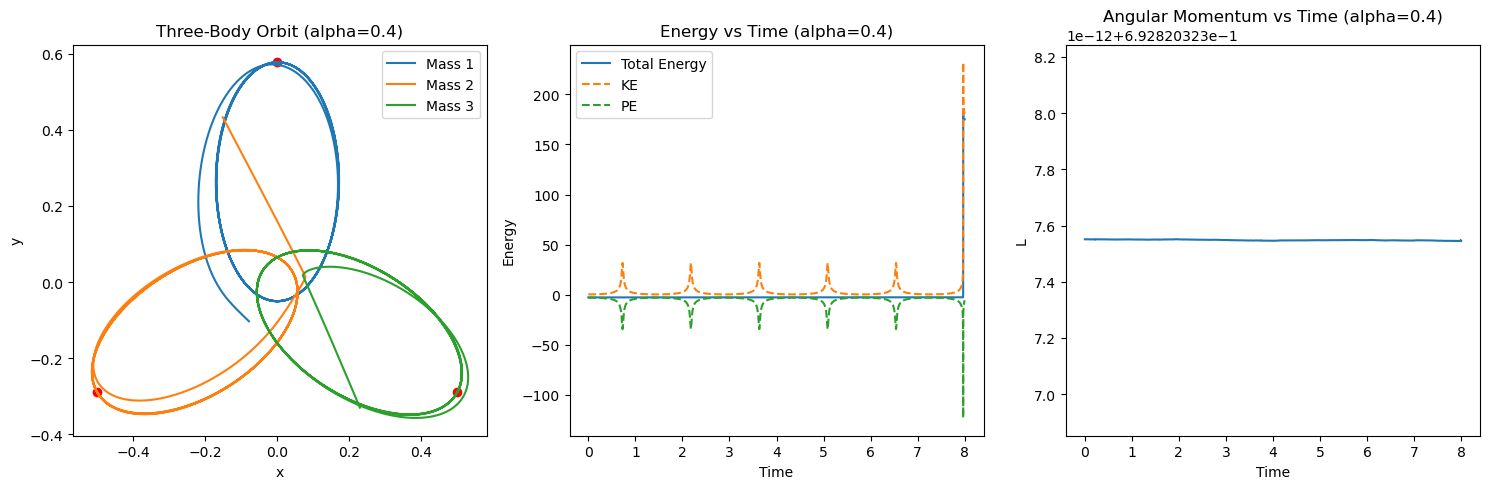

In [29]:
# Plot the alpha = 0.4 trajectory for a shorter time
alpha = 0.4
dt = 0.001
total_t = 8.0
N = int(total_t / dt)
t = np.linspace(0, total_t, N+1)

v1_scaled, v2_scaled, v3_scaled = scale(alpha, v1_Lagrange, v2_Lagrange, v3_Lagrange)
results = velocity_verlet_3body(r1_Lagrange, r2_Lagrange, r3_Lagrange,
                                v1_scaled, v2_scaled, v3_scaled, m_Lagrange, G, dt, N)

r1_new = results[0]
r2_new = results[1]
r3_new = results[2]
KE = results[6]
PE = results[7]
E_total = results[8]
L = results[9]
    
# Plot the orbit
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.plot(r1_new[:,0], r1_new[:,1], label="Mass 1")
plt.plot(r2_new[:,0], r2_new[:,1], label="Mass 2")
plt.plot(r3_new[:,0], r3_new[:,1], label="Mass 3")
plt.scatter(r1_new[0,0], r1_new[0,1], color="red")  
plt.scatter(r2_new[0,0], r2_new[0,1], color="red")
plt.scatter(r3_new[0,0], r3_new[0,1], color="red")
plt.xlabel("x")
plt.ylabel("y")
plt.title('Three-Body Orbit (alpha=0.4)')
plt.legend(loc='best')

# Plot total energy
plt.subplot(1,3,2)
plt.plot(t, E_total, label="Total Energy")
plt.plot(t, KE, label="KE", linestyle="--")
plt.plot(t, PE, label="PE", linestyle="--")
plt.xlabel("Time")
plt.ylabel("Energy")
plt.title('Energy vs Time (alpha=0.4)')
plt.legend(loc='best')
    
# Plot angular momentum
plt.subplot(1,3,3)
plt.plot(t, L)
plt.xlabel("Time")
plt.ylabel("L")
plt.title('Angular Momentum vs Time (alpha=0.4)')
    
plt.tight_layout()
plt.show()

Now we can clearly see that because the tangential speeds are below the ideal Lagrange value, the bodies cannot remain at a safe separation indefinitely. Their orbits become highly elliptical, and at a certain moment two of the bodies come too close to each other and flung each other outward. 

We can conclude that scaling the initial velocity magnitude leads to different behaviours of the system:
- Scaling factor $\alpha < 0.5$ or $\alpha>1.25$ : unstable orbits, e.g. bodies came to a near-collision and got swung out, all bodies eject due to high velocity
- Scaling factor $\alpha$ between $0.5$ and $1.25$ : stable (at least in short-term) but not necessarily equilateral orbits

### 2. Simulating Triple-star System: Alpha Centauri

**2025/03/21**

For the last section of this notebook, I want to investigate the **triple-star system: Alpha Centauri**. 

In one of my favourite Sci-Fi novels *The Three-Body Problem*, an alien race, known as the Trisolarians, inhabits a planet orbiting a nearby triple-star system, known as Alpha Centauri. This triple-star system consists of three stars with similar masses that follow chaotic, unpredictable orbits, causing the planet to have extremely hostile habitats for life.

The Alpha Centauri in reality, however, is quite different from the one in the story. Despite also being a triple-star system, the three stars in the real Alpha Centauri do not all have similar masses:
- Alpha Centauri A (a G2V star, about 1.1 times solar mass)
- Alpha Centauri B (a K1V star, about 0.9 times solar mass)
- Proxima Centauri (an M dwarf, the smallest and most distant component, about 0.12 times solar mass)

Therefore, by reusing my velocity Verlet integrator function, I want to first simulate the orbit of the real Alpha Centauri based on real data. And then I will explore the Sci-Fi Alpha Centauri: tweak masses to be equal, pick more chaotic initial conditions, watch the triple system behave in a “Trisolaran” way. This bridges the **actual** Alpha Centauri data and the **fictional** scenario from *The Three-Body Problem*, and hopefully we can see some interesting results!

### 2.1 Simulating the Real Alpha Centauri
#### 2.1.1 Gather Real Data$^{[2]}$ 
##### 1. Alpha Centauri A & B (these two are often considered as a binary system)
   - $\alpha$ Cen A : Mass $\approx 1.1055 M_{sol}$
   - $\alpha$ Cen B : Mass $\approx 0.9373 M_{sol}$
   - Orbital parameters for this A-B pair: Semi-major axis $\approx 23.4AU$, Orbital period $\approx 79.91$ years
##### 2. Proxima Centauri
   - Mass $\approx 0.1221 M_{sol}$
   - Semi-major axis $\approx 8700 AU$
   - For my simulation, I will choose a representative value (e.g. $10000 AU$) to illustrate its long orbital period.

#### 2.1.2 Convert data into consistent units
To create an accurate simulation of the real $\alpha$ Cen orbit, first we need to convert masses and distances to a consistent set of units and calculate the gravitational constant $G$ accordingly.
##### 1. Pick a Unit System
A good choice of unit system for realistic stellar orbital simulations":
1. Mass unit: Solar masses $(M_{sol})$
2. Distance unit: Astronomical units $(AU)$
3. Time unit: Years $(yr)$
   
We can calculate the gravitational constant $G$ in these units simply converting all the units from SI units. Eventually the value we will obtain is approximately: $G = 39.478$.

##### 2. Convert masses
The data we gathered for the masses are already in units of solar mass:
- $\alpha$ Cen A : Mass $\approx 1.1055 M_{sol}$
- $\alpha$ Cen B : Mass $\approx 0.9373 M_{sol}$
- Proxima Centauri :  Mass $\approx 0.1221 M_{sol}$
##### 3. Convert distances
The data we gathered for the distances are already in units of $AU$:
- Semi-major axis for $\alpha$ Cen A-B pair : $\approx 23.4AU$
- Semi-major axis for Proxima Centauri and the A-B pair: $\approx 8700AU$

#### 2.1.3 Calculate initial conditions
##### 1. For $\alpha$ Cen A and B ( the close binary)
In the real $\alpha$ Cen system, the orbit of the A-B pair is eccentric. However, we can assume a circular orbit for simplicity in our simulation:
- Separation $\approx 23.4 AU$
- $\alpha$ Cen A : Mass $\approx 1.1055 M_{sol}$, $\alpha$ Cen B : Mass $\approx 0.9373 M_{sol}$
- Orbital period $\approx 79.91$ years

We place the binary's barycenter at the origin $(0,0,0)$, and locate A and B along the x-axis.

By the Centre of Mass formula we can find their initial positions:

$\alpha$ Cen A = $(-10.6, 0, 0) AU$, $\alpha$ Cen B = $(12.8, 0, 0) AU$

Since we assume circular orbit, we can quickly find the orbital speed from the separation and orbital period to be about $1.84$AU/yr. However because they have different masses, their speeds need to be scaled:
$$ v_A = \frac{m_B}{m_A+m_B} \times 1.84 = 0.831 , v_B = \frac{m_A}{m_A+m_B} \times 1.84 = 1.009$$
Then we assign velocities perpendicular to the x-axis (i.e. along y) with opposite directions: 

$\alpha$ Cen A = $(0, +0.831, 0) AU/yr$, $\alpha$ Cen B = $(0, -1.009, 0) AU/yr$

##### 2. For Proxima Centauri
From published data:
- Semi-major axis: $ a \approx 8700AU$
- Eccentricity: $e \approx 0.50$

Thus, the periapsis distance$^{[3]}$ is:
$$ r_{per} = a(1-e) = 8700 \times 0.5 = 4350 AU$$
Total mass of the system is roughly:
$$m_{tot} = 1.10 +0.91+0.12 \approx 2.12 M_{sol}$$
Using the vis-viva equation at periastron:
$$ v_{per} = \sqrt{G m_{tot} (\frac{2}{r_{per}} - \frac{1}{a})}$$
We get $v\approx 0.1716 AU/yr$.

For Proxima's orbital orientation we take the published orbital elements:
- Inclination: $ i = 107.6°$
- Longitude of the ascending node: $\Omega = 126°$
- Argument of periastron: $\omega = 72.3°$

In the perifocal frame (the orbital plane), we place Proxima at periastron:
- Position: $\mathbf r_{pf} = (r_{per},0,0)AU = (4350,0,0)AU$
- Velocity: $\mathbf v_{pf} = (0,v_{per},0)AU/yr = (0,0.1716,0)AU/yr$

We then convert these into 3D inertial frame$^{[4]}$  using the standard rotation matrices:
$$ \mathbf r = R_z (-\Omega)R_x(-i)R_z(-\omega)\mathbf r_{pf}$$
$$ \mathbf v = R_z (-\Omega)R_x(-i)R_z(-\omega)\mathbf v_{pf}$$
where the rotation matrices are defined as:
$$R_z(\theta) = \begin{pmatrix} cos\theta & -sin\theta & 0 \\ sin\theta & cos\theta & 0 \\ 0 & 0 & 1\end{pmatrix} , R_x(\theta) = \begin{pmatrix} 1 & 0 & 0 \\ 0 & cos\theta & -sin\theta \\ 0 & sin\theta & cos\theta \end{pmatrix}$$

After conversion, we find the initial conditions of Proxima in 3D to be:
- $\mathbf r_{proxima} \approx (246, -1792, 3954) AU$
- $\mathbf v_{proxima} \approx (-0.109, -0.123, -0.049) AU/yr$

##### Final simplied initial conditions:
- $\alpha$ Cen A:
  - Position: $\mathbf r_A = (-10.6,0,0)AU$
  - Velocity: $\mathbf v_A = (0,0.831,0)AU/yr$
- $\alpha$ Cen B:
  - Position: $\mathbf r_B = (12.8,0,0)AU$
  - Velocity: $\mathbf v_B = (0,-1.009,0)AU/yr$
- Proxima Centauri:
  - Position: $\mathbf r_{proxima} \approx (246, -1792, 3954) AU$
  - Velocity: $\mathbf r_{proxima}  \approx (-0.109, -0.123, -0.049) AU/yr$

These initial conditions — combined with a gravitational constant of $G \approx 39.478 AU^3/(M_{sol}  yr^2)$ allow us to integrate the motions of the three bodies using the velocity Verlet method.

#### 2.1.4 Create a 3D force function
The `three_body_forces` function we computed before cannot be used now, since it takes in 2D position arrays and return 2D vector for the force. Also, it only takes one value for m, since we set all masses to be the same back in the last section. 

Therefore, we are going to compute a new function,`three_body_forces_3d`, that returns a 3D force array for three different masses.

In [34]:
# Define a function to compute gravitational force on each mass for the velocity Verlet update loop
def three_body_forces_3d(r1,r2,r3,m1,m2,m3,G):
    """Compute the net gravitational force on three bodies.
    Inputs:
    - r1,r2,r3    Position vectors of the 3 bodies (array with 3 elements)
    - m1,m2,m3    Masses of the 3 bodies
    - G           Gravitational constant
    
    Returns:
    F1,F2,F3: 3D force vectors on body 1,2,3 respectively.
    """
    F1 = np.zeros(3)
    F2 = np.zeros(3)
    F3 = np.zeros(3)
    
    # Force on 1 from 2 and 3
    r12 = r2-r1
    r13 = r3-r1
    F1 += G*m1*m2*r12 / (np.linalg.norm(r12)**3)
    F1 += G*m1*m3*r13 / (np.linalg.norm(r13)**3)
    # Force on 2 from 1 and 3
    r21 = r1-r2
    r23 = r3-r2
    F2 += G*m2*m1*r21 / (np.linalg.norm(r21)**3)
    F2 += G*m2*m3*r23 / (np.linalg.norm(r23)**3)
    # Force on 3 from 1 and 2
    r31 = r1-r3
    r32 = r2-r3
    F3 += G*m3*m1*r31 / (np.linalg.norm(r31)**3)
    F3 += G*m3*m2*r32 / (np.linalg.norm(r32)**3)
    
    return F1, F2, F3

#### 2.1.5 Create a 3D velocity Verlet Integrator function
Again, the `velocity_verlet_3body` function we computed in the previous section cannot be used now, since it takes in 2D position arrays and only takes one value for m.

We are going to compute a new function,`velocity_verlet_3body_3d`, that runs the velocity Verlet update loop for 3D three body problems.

In [36]:
# Function of velocity Verlet Integrator for the 3D 3-body system
def velocity_verlet_3body_3d(r1_init, r2_init, r3_init, 
                             v1_init, v2_init, v3_init, m1, m2, m3, G, dt, N):
    """
    Propagate a 3D three-body system using the velocity Verlet method
    
    Inputs:
    - r1_init, r2_init, r3_init   Initial positions (each a 3-element array)
    - v1_init, v2_init, v3_init   Initial velocities (each a 3-element array)
    - m1, m2, m3                  Mass of each body
    - G                           Gravitational constant
    - dt                          Timestep
    - N                           Number of steps
      
    Returns:
      r1, r2, r3: position arrays of shape (N+1,3)
      v1, v2, v3: velocity arrays of shape (N+1,3) 
    """
    # Set up arrays to store positions and velocities
    r1 = np.zeros((N+1,3))
    r2 = np.zeros((N+1,3))
    r3 = np.zeros((N+1,3))
    v1 = np.zeros((N+1,3))
    v2 = np.zeros((N+1,3))
    v3 = np.zeros((N+1,3))

    # Set initial conditions
    r1[0] = r1_init
    r2[0] = r2_init
    r3[0] = r3_init
    v1[0] = v1_init
    v2[0] = v2_init
    v3[0] = v3_init
    
    # Compute initial forces
    F1, F2, F3 = three_body_forces_3d(r1_init, r2_init, r3_init, m1, m2, m3, G)
    
    # Time integration loop
    for i in range(N):
        # Update positions
        r1_new = r1[i] + v1[i]*dt + 0.5*(F1/m1)*dt**2
        r2_new = r2[i] + v2[i]*dt + 0.5*(F2/m2)*dt**2
        r3_new = r3[i] + v3[i]*dt + 0.5*(F3/m3)*dt**2
        # Compute new forces at updated positions
        F1_new, F2_new, F3_new = three_body_forces_3d(r1_new, r2_new, r3_new, m1, m2, m3, G)
        # Update velocities
        v1_new = v1[i] + 0.5*((F1+F1_new)/m1)*dt
        v2_new = v2[i] + 0.5*((F2+F2_new)/m2)*dt
        v3_new = v3[i] + 0.5*((F3+F3_new)/m3)*dt
        # Store new positions and velocities
        r1[i+1] = r1_new
        r2[i+1] = r2_new
        r3[i+1] = r3_new
        v1[i+1] = v1_new
        v2[i+1] = v2_new
        v3[i+1] = v3_new
        # Update forces for next iteration
        F1, F2, F3 = F1_new, F2_new, F3_new
        
    return r1, r2, r3, v1, v2, v3

#### 2.1.6 Run the velocity Verlet loop
The next step is to implement the initial conditions that we calculated, then run the loop and plot the orbit!

**2025/03/21**: In the first attempt of running the velocity Verlet loop, the plot showed that Alpha Centauri A and B flies away from each other, leaving two nearly straight trajectories that are each about 600AU long. I later found that it is due to incorrect initial velocities. I set them to have identical speed of 1.84AU/yr, but in opposite directions. The correct way to calculate their initial velocities should be scaling the speed with their mass. After fixing this calculation error, I got plots with orbits that look much more reasonable.

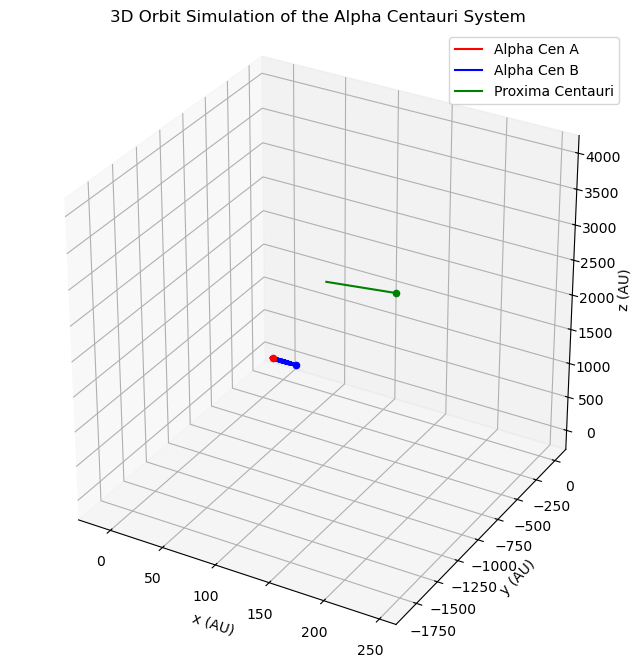

In [38]:
# Initial conditions in our chosen unit system
G = 39.478
m_A = 1.1055
m_B = 0.9373
m_Prox = 0.1221
r_A_init = np.array([-10.6, 0.0, 0.0])   
r_B_init = np.array([12.8, 0.0, 0.0]) 
v_A_init = np.array([0.0, 0.831, 0.0])
v_B_init = np.array([0.0, -1.009, 0.0])
r_Prox_init = np.array([246.0, -1792.0, 3954.0])
v_Prox_init = np.array([-0.109, -0.123, -0.049])

# Run simulation
dt = 0.05
total_t = 500  # run for 500 years
N = int(total_t/dt)
r_A, r_B, r_Prox, v_A, v_B, v_Prox = velocity_verlet_3body_3d(r_A_init, r_B_init, r_Prox_init,
                                                              v_A_init, v_B_init, v_Prox_init,
                                                              m_A, m_B, m_Prox, G, dt, N)

# Create 3D plot
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')
ax.plot(r_A[:,0], r_A[:,1], r_A[:,2], label="Alpha Cen A", color="red")
ax.plot(r_B[:,0], r_B[:,1], r_B[:,2], label="Alpha Cen B", color="blue")
ax.plot(r_Prox[:,0], r_Prox[:,1], r_Prox[:,2], label="Proxima Centauri", color="green")
ax.scatter(r_A_init[0], r_A_init[1], r_A_init[2], color="red")  
ax.scatter(r_B_init[0], r_B_init[1], r_B_init[2], color="blue")
ax.scatter(r_Prox_init[0], r_Prox_init[1], r_Prox_init[2], color="green")
ax.set_xlabel("x (AU)")
ax.set_ylabel("y (AU)")
ax.set_zlabel("z (AU)")
ax.set_title("3D Orbit Simulation of the Alpha Centauri System")
ax.set_box_aspect((1,1,1))
ax.legend(loc='best')
plt.show()

We can see that within 500 years, Alpha Cen A and B seem to have completed several orbits (we can't really see the details of their movements in this large plot), while Proxima has only just drifted slightly. This observation is expected since Proxima is so distant away from the pair. 

From published data, the orbital period of Proxima Centauri is on the order of 550,000 years, so in just a few hundred years, it barely moves from its starting position. Running velocity Verlet for such a long period of time is obviously **very** computationally expensive, and floating-point round-off errors would accumulate. So, unfortunately, we cannot simulate a full orbit of Proxima Centauri.

We can zoom in to the A-B pair to look closer at their orbits though.

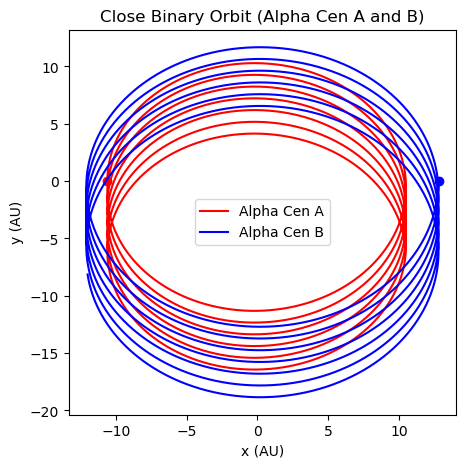

In [40]:
# Zoom in to plot detailed orbits of Alpha Cen A and B only:
plt.figure(figsize=(5,5))
plt.plot(r_A[:,0], r_A[:,1], label="Alpha Cen A", color="red")
plt.plot(r_B[:,0], r_B[:,1], label="Alpha Cen B", color="blue")
plt.scatter(r_A_init[0], r_A_init[1], color="red")
plt.scatter(r_B_init[0], r_B_init[1], color="blue")
plt.xlabel("x (AU)")
plt.ylabel("y (AU)")
plt.title("Close Binary Orbit (Alpha Cen A and B)")
plt.legend(loc='best')
plt.show()

This plot looks quite similar to the plots we got in section 1.2 and 2.2, where we simulated two similar masses orbiting their centre of mass, except in this plot orbits are elliptical and not enclosed. However, the orbit looks stable, which implies that the gravitational effect of Proxima Centauri on the A-B pair is **very weak**. This triple-star system **do not exhibit a chaotic behaviour** (at least in the first 500 years).

In fact, we can try to eliminate Proxima Centauri from the simulation to generate isolated orbits of the A-B pair to compare with this non-isolated orbit.

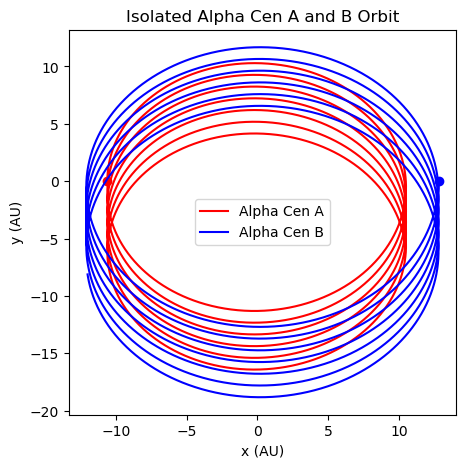

In [42]:
# Run simulation for m_Proxima aprrxoimately = zero
dt = 0.05
total_t = 500  # run for 500 years
N = int(total_t/dt)
m_Prox = 1e-10  # Set m_Proxima to a very small value to eliminate its gravitational effects
r_A, r_B, r_Prox, v_A, v_B, v_Prox = velocity_verlet_3body_3d(r_A_init, r_B_init, r_Prox_init,
                                                              v_A_init, v_B_init, v_Prox_init,
                                                              m_A, m_B, m_Prox, G, dt, N)
plt.figure(figsize=(5,5))
plt.plot(r_A[:,0], r_A[:,1], label="Alpha Cen A", color="red")
plt.plot(r_B[:,0], r_B[:,1], label="Alpha Cen B", color="blue")
plt.scatter(r_A_init[0], r_A_init[1], color="red")
plt.scatter(r_B_init[0], r_B_init[1], color="blue")
plt.xlabel("x (AU)")
plt.ylabel("y (AU)")
plt.title("Isolated Alpha Cen A and B Orbit")
plt.legend(loc='best')
plt.show()

This isolated orbit of Alpha Centauri A and B looks almost identical to the one with gravitational effects of Proxima Centauri. This verifies our guess: The Alpha Centauri A-B pair have very stable orbit around their centre of mass, with or without Proxima Centauri. This explains why astrophysicists often approximate Alpha Centauri as a **stable binary system** instead of a triple-star system. 

On long timescales, or in very precise orbital studies, Proxima’s presence does matter. But for many practical purposes, Alpha Centauri is approximated as a two‐body system with a distant third component. This type of triple-star configurations is called **hierarchical** configurations$^{[5]}$ - a tight inner binary orbited by a distant third star.

#### 2.1.7 Conslusion
From this simulation of the real Alpha Centauri system, we can conclude that in three‑body systems—where one body (or pair) is much more tightly bound than the third: the system’s dynamics can often be **approximated as a two‑body problem** for many practical purposes. For example:
- When the third body is very distant and/or of much lower mass compared to the close binary, its gravitational effect on the inner pair is minimal over short (to intermediate) timescales.
- We've shown that the inner binary (Alpha Centauri A and B) can be treated as a stable two‑body system, with Proxima’s influence considered only as a small, slowly varying perturbation.
- Such an approximation can simplify analysis on the orbits significantly since two‑body problems have closed‑form solutions and are much easier to predict.
- However, over very long timescales or if the masses and separations are comparable, the three‑body dynamics can become chaotic and requires to be treated as a three‑body system.

### 2.2 Simulating the "Fictional Alpha Centauri"

**2025/03/22**

In the science-fiction novel *The Three-Body Problem*, the Alpha Centauri system is reimagined as three comparable stars labeled A, B, and C — whose orbits around one another are so irregular and chaotic that the planet in the system (known as “Trisolaris”) experiences extreme, unpredictable environmental changes. In this scenario, star C is placed on a highly irregular trajectory that repeatedly perturbs the other two stars’ more stable orbits, creating short “Stable Eras” separated by "Chaotic Eras" on the planet Trisolaris.

In this section, we do not explicitly include a planet because its mass and distance would not significantly alter the chaotic star–star interactions. We will focus on demonstrating how adjusting the mass and initial conditions of star C can transform a well-behaved binary system (like the real Alpha Centauri A–B) into a chaotic three-star system reminiscent of the novel.

#### 2.2.1 Setting up Initial Conditions
The same set of solar units (and thus value for $G$) will be used.
We will keep the same initial positions and velocities for stars A and B that we used in our realistic Alpha Centauri simulation. They will have a supposedly stable orbit around their barycenter (which is at the origin). 

- $\alpha$ Cen A:
  - Position: $\mathbf r_A = (-10.6,0,0)AU$
  - Velocity: $\mathbf v_A = (0,0.831,0)AU/yr$
  - Mass $\approx 1.1055 M_{sol}$
- $\alpha$ Cen B:
  - Position: $\mathbf r_B = (12.8,0,0)AU$
  - Velocity: $\mathbf v_B = (0,-1.009,0)AU/yr$
  - Mass $\approx 0.9373 M_{sol}$

We then replace the real Proxima Centauri parameters with new values for star C. In the story, the three stars have similar masses, so we can simply set the mass of star C to be $1.0M_{sol}$. 

Then we will vary the initial position and velocities and test over a range of values. We can introduce an effect of inclination of the orbit of star C:
- Parameters to test for $\alpha$ Cen C:
  - Distance from the origin $d_C$: $30, 50, 100, 200$ (AU)
  - Position: $\mathbf r_C = (d_C,0,0)$AU
  - Inclination $i$: $10°,20°,30°$
  - Speed: $v_C = 0.5, 1.0, 2.0$ AU/yr
  - Velocity: $\mathbf v_C = (0,v_C cos(i) ,v_C sin(i))$ AU/yr



#### 2.2.2 Run simulation for each set of test values

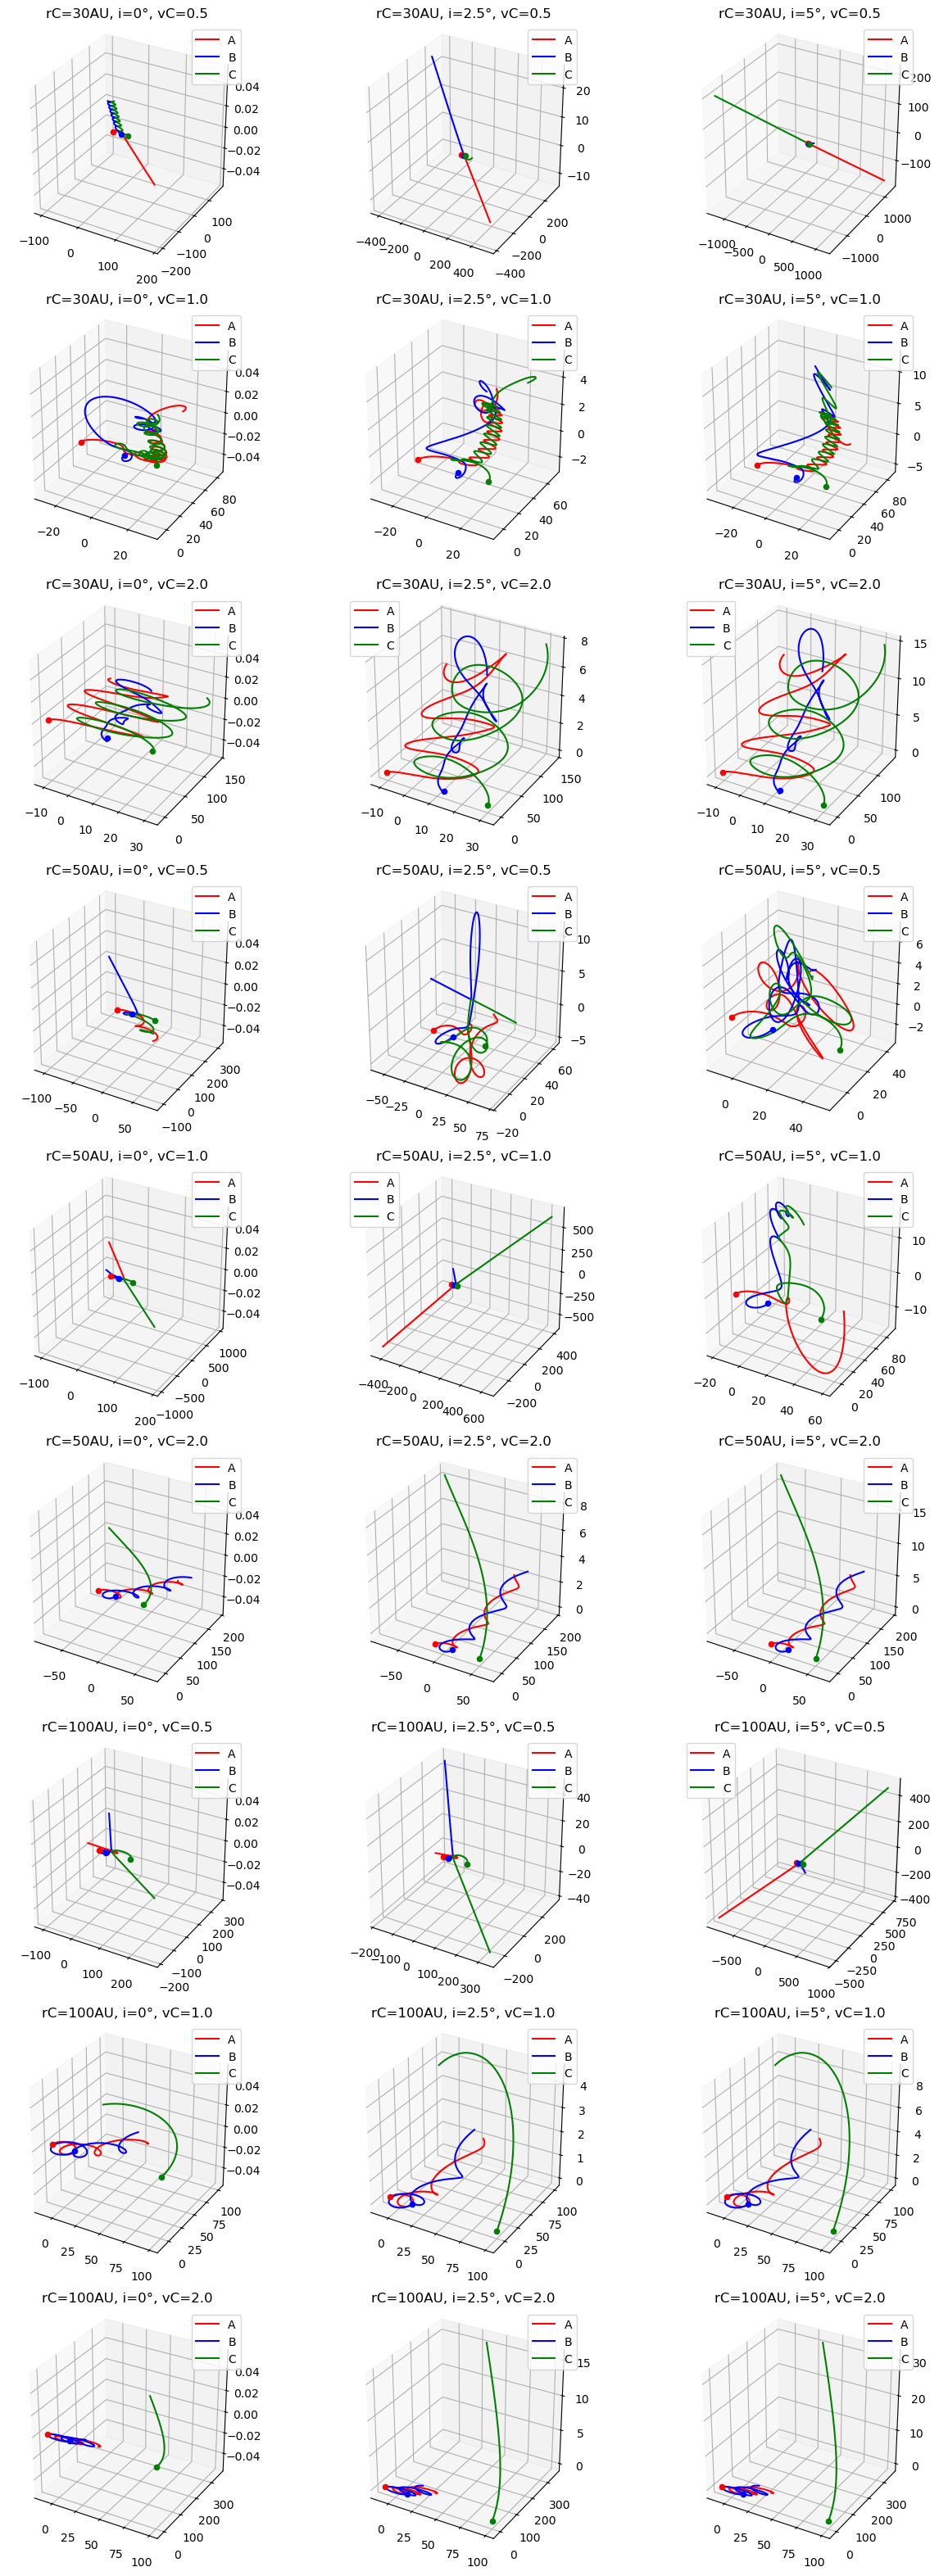

In [46]:
# Initial conditions
G = 39.478
m_A = 1.1055
m_B = 0.9373
m_C = 1.0  
r_A_init = np.array([-10.6, 0.0, 0.0])   
r_B_init = np.array([12.8, 0.0, 0.0]) 
v_A_init = np.array([0.0, 0.831, 0.0])
v_B_init = np.array([0.0, -1.009, 0.0])

# List of values to test for star C
distances = [30, 50, 100]   
inclinations = [0, 2.5, 5]
speeds = [0.5, 1.0, 2.0]

# Run simulation for 200 years for each set of values
dt = 0.05          
total_t = 200.0   
N = int(total_t / dt)

# Loop over the different scenarios
results = []  # list to store results for plotting 

# We'll have 27 total scenarios (3 distances × 3 inclinations × 3 speeds)
fig3d = plt.figure(figsize=(15,40))  # make it big enough
nplots = len(distances)*len(inclinations)*len(speeds)
idx = 1  # subplot counter

for rC in distances:
    for vC in speeds:
        for degrees in inclinations:
            radians = np.deg2rad(degrees)  # Convert inclination degrees to radians
        
            # position of star C 
            r_C_init = np.array([rC, 0.0, 0.0])
        
            # velocity: vC_y = vC*cos(i), vC_z = vC*sin(i)
            v_C_init = np.array([0.0, vC*np.cos(radians), vC*np.sin(radians)])
        
            # Run the velocity Verlet integrator
            r_A, r_B, r_C, v_A, v_B, v_C = velocity_verlet_3body_3d(
            r_A_init, r_B_init, r_C_init,
            v_A_init, v_B_init, v_C_init,
            m_A, m_B, m_C, G, dt, N)
        
            # Store the results and label the scenario
            scenario = f"rC={rC}AU, i={degrees}°, vC={vC}"
            results.append({'label':scenario,'r_A':r_A, 'r_B':r_B, 'r_C':r_C})
            
            # Create a subplot of 9 rows x 3 columns for 27 scenarios
            ax3d = fig3d.add_subplot(9, 3, idx, projection='3d')  
            ax3d.plot(r_A[:,0], r_A[:,1], r_A[:,2], label="A", color='red')
            ax3d.plot(r_B[:,0], r_B[:,1], r_B[:,2], label="B", color='blue')
            ax3d.plot(r_C[:,0], r_C[:,1], r_C[:,2], label="C", color='green')
            ax3d.scatter(r_A_init[0], r_A_init[1], r_A_init[2], color='red')
            ax3d.scatter(r_B_init[0], r_B_init[1], r_B_init[2], color='blue')
            ax3d.scatter(r_C_init[0], r_C_init[1], r_C_init[2], color='green')
            ax3d.set_title(f"{scenario}")
            ax3d.set_box_aspect((1,1,1))
            ax3d.legend()
            
            idx += 1 


plt.show()

#### 2.2.3 Interpretation of the orbits
##### Key observations from the plot:
1. Closer distances lead to stronger perturbations
   - In the plots where $r_C$ is only 30-50 AU, star C's orbit intersects or stays close to the region of stars A and B.
   - This proximity leads to more visible “twisting” or “bending” of each star’s path, indicating stronger mutual gravitational influence.
   - In contrast, at 100 AU, star C’s orbit is more loosely coupled; we see star C mostly looping out at a distance, while A–B remain relatively confined.
2. Inclination amplifies 3D motion
   - Even small inclinations can cause the orbits to spiral in 3D rather than remaining nearly in a single plane.
   - The slight tilt can cause repeated out-of-plane encounters, further mixing or “braiding” the paths (e.g. the rC=50AU, inclination=5°, vC = 0.5AU/yr plot).
   - This is consistent with how non-coplanar orbits can lead to more complex interactions.
3. Lower initial speed of Star C leads to more perturbations
   - In the plots where $v_C= 0.5$, the orbits are more chaotic and irregular than those of $v_C= 2.0$.
   - This is because with lower speed, star C is drawn in closer to the A-B pair, causing stronger gravitational perbutations to the pair.
   - With higher speed, star C "lift off" more quickly from the A-B region, thus has less influence on the A-B orbits.
4. Most of the orbits are unstable
   - Almost all orbits (except those with long distance and high velocities) are unstable. Many of them show at least one star being ejected, and if we run the simulation for a longer period this is likely to happen for all the unstable orit plots.
   - This implies the small possibility to find a long-living non-hierarchical triple-star system.

#### 2.2.4 Conclusion on the "Fictional" Alpha Centauri
In this section, we introduced a fictional Alpha Centauri C with varying distances, speeds, and inclinations relative to the stable Alpha Cen A–B pair. 

Our simulations show that when star C is sufficiently close, slow, or inclined, the system quickly becomes chaotic — often leading to ejections. These findings align with the theoretical expectation that non-hierarchical triple-star configurations are inherently unstable, while more “hierarchical” setups remain more stable. 

Therefore we can conclude that in the novel *The Three Body Problem*, the depiction of Alpha Centauri as a chaotic triple system where all three stars interact strongly and unpredictably is probably just designed for dramatic effect. From a physical standpoint, such a configuration is likely to be very short-lived unless the parameters are **finely tuned***.

So, while the novel’s setting creates a compelling narrative, it does seem to be less realistic compared to what we observe in actual triple-star systems, where they usually have the third star at a large distance.

###### *: While our simulations demonstrate that a chaotic triple-star configuration — as depicted in The Three-Body Problem — is highly unstable unless its parameters are exceptionally fine-tuned, we might also view this fine-tuning from a philosophical perspective. In a manner reminiscent of the cosmic fine-tuning argument, it could be argued that such precise conditions might not be entirely coincidental. In other words, the ‘fine-tuned’ nature of these chaotic parameters could, in principle, give rise to unique astrophysical environments — such as those imagined in the novel, where the extreme and unpredictable dynamics lead to the existence of the Trisolarans. However it is important to note that statistically, stable binary or single-star systems are far more likely to provide the steady conditions that favour the development of life, on top of the fact that such a non-hierarchical triple-star system is very unlikely to exist. I find this dual perspective interesting so I added this as a side note.

## Conclusion 

In this logbook, we applied the velocity Verlet integrator to simulate three-body gravitational dynamics, focusing on the evolution of both stable and chaotic systems. We started by investigation of the classic Lagrange solution to the three-body problem, and experimented with scaled velocities to test the stability of the solution. 

We then used published data to set up realistic initial conditions for the Alpha Centauri system and then extended our simulations by varying the parameters for the third star. By systematically varying star C’s distance, velocity, and inclination, we demonstrated how small changes in initial conditions can drive the system from near two-body stability to chaotic behavior such as star ejections. 

These findings not only validate our computational methods but also provide insight into triple-star systems. Overall, this logbook illustrates the critical role of initial conditions in multi-body dynamics and deepens our understanding of chaos in physical systems.

### References:

[1]: Gareth E. Roberts: Linear Stability of the Elliptic Lagrangian Triangle Solutions in the Three-Body Problem, *Journal of Differential Equations 182, 191–218*, 2002

[2]: P. Kervell et al.: Proxima’s orbit around $\alpha$ Centauri, *Astronomy & Astrophysics*, 2017

[3]: Emily Lakdawalla: Figuring out orbital positions from orbital elements, *The Planetary Society*, *https://www.planetary.org/articles/3380*

[4]: orbital-mechanics.space : *https://orbital-mechanics.space/classical-orbital-elements/orbital-elements-and-the-state-vector.html*

[5]: Heintz, W.D.: *Double Stars. D. Reidel Publishing Company, Dordrecht. pp. 66–67*, 1978